# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import glob
import requests

# Merging all of the CSVs into two dataframes, one for actual, one for forecasts. Then, converting all date time columns to datetime object and sorting said columns in ascending order

In [2]:
actual_files = sorted(glob.glob("../data/pjm/data-miner-2/load_actual_*.csv"))
forecast_files = sorted(glob.glob("../data/pjm/data-miner-2/load_forecast_*.csv"))

load_actual_df = pd.concat([pd.read_csv(f) for f in actual_files], ignore_index=True)
load_forecast_df = pd.concat([pd.read_csv(f) for f in forecast_files], ignore_index=True)

load_actual_df["datetime_beginning_utc"] = pd.to_datetime(load_actual_df["datetime_beginning_utc"])
load_forecast_df["evaluated_at_utc"] = pd.to_datetime(load_forecast_df["evaluated_at_utc"])
load_forecast_df["forecast_hour_beginning_utc"] = pd.to_datetime(load_forecast_df["forecast_hour_beginning_utc"])

load_actual_df = load_actual_df.sort_values(by="datetime_beginning_utc").reset_index(drop=True)
load_forecast_df = load_forecast_df.sort_values(by="forecast_hour_beginning_utc").reset_index(drop=True)

# Drop all of the columns relating to EPT, we only want to work in UTC

In [3]:
load_actual_df = load_actual_df.drop("datetime_beginning_ept", axis="columns")

load_forecast_df = load_forecast_df.drop(["evaluated_at_ept", "forecast_hour_beginning_ept"], axis="columns")

# The load forecast data available from the PJM uses what is called "forecast_area". Of the forecast areas available, only some of them are present in the load forecast dataset and the load actual dataset. We will continue and do all future analyses only on the "forecast_area" present in both.

In [4]:
common_areas = ["AEP", "ATSI", "DAY", "DEOK", "DOM", "DUQ", "EKPC", "OVEC"]

# Useful functions

In [5]:
def get_actual_loads(load_actual_df, datetime_beginning_utc, zone):
    """
    Prints all actual load values for a given zone and timestamp,
    including the different load areas and the total sum of all load areas.

    Parameters:
        load_actual_df (pd.DataFrame): Pandas DataFrame containing actual load data.
        datetime_beginning_utc (str or datetime): The target timestamp in UTC.
        zone (str): The zone to filter by.

    Returns:
        None (prints the results).
    """
    datetime_beginning_utc = pd.to_datetime(datetime_beginning_utc)

    filtered_df = load_actual_df[
        (load_actual_df["datetime_beginning_utc"] == datetime_beginning_utc) &
        (load_actual_df["zone"] == zone)
    ]

    if filtered_df.empty:
        print(f"No actual load data found for {zone} at {datetime_beginning_utc}.")
    else:
        print(f"Actual Load MW values for {zone} at {datetime_beginning_utc}:")

        total_load = filtered_df["mw"].sum()

        print(filtered_df[["load_area", "mw"]].to_string(index=False))

        print(f"\nTotal Load MW for {zone}: {total_load}")


In [6]:
def get_total_actual_load(load_actual_df, datetime_beginning_utc, zone):
    """
    Returns the total actual load for a given zone and timestamp.

    Parameters:
        load_actual_df (pd.DataFrame): DataFrame containing actual load data.
        datetime_beginning_utc (str or datetime): The target timestamp in UTC.
        zone (str): The zone to filter by.

    Returns:
        float or None: The total actual load MW for the given zone and time, or None if no data is found.
    """
    datetime_beginning_utc = pd.to_datetime(datetime_beginning_utc)

    total_load = load_actual_df.loc[
        (load_actual_df["datetime_beginning_utc"] == datetime_beginning_utc) &
        (load_actual_df["zone"] == zone), "mw"
    ].sum()

    return total_load if total_load != 0 else None

In [7]:
get_actual_loads(load_actual_df, "2020-01-01 05:00:00", "AEP")

print("\n")
print("Test to confirm total actual load getter method works:")
print(get_total_actual_load(load_actual_df, "2020-01-01 05:00:00", "AEP"))

Actual Load MW values for AEP at 2020-01-01 05:00:00:
load_area       mw
   AEPAPT 4294.077
   AEPIMP 2683.729
   AEPKPT  675.489
   AEPOPT 5671.164

Total Load MW for AEP: 13324.458999999999


Test to confirm total actual load getter method works:
13324.458999999999


In [8]:
def get_forecast_loads(load_forecast_df, forecast_hour_beginning_utc, forecast_area):
    """
    Prints all forecasted load values for a given forecast hour and forecast area,
    including the time each forecast was made.

    Parameters:
        load_forecast_df (pd.DataFrame): DataFrame containing forecast data.
        forecast_hour_beginning_utc (str or datetime): The target forecast hour in UTC.
        forecast_area (str): The forecast area to filter by.

    Returns:
        None (prints the results).
    """
    forecast_hour_beginning_utc = pd.to_datetime(forecast_hour_beginning_utc)

    filtered_df = load_forecast_df.loc[
        (load_forecast_df["forecast_hour_beginning_utc"] == forecast_hour_beginning_utc) &
        (load_forecast_df["forecast_area"] == forecast_area)
    ]

    if filtered_df.empty:
        print(f"No forecast data found for {forecast_hour_beginning_utc} in {forecast_area}.")
    else:
        print(f"Forecasted load MW values for {forecast_hour_beginning_utc} in {forecast_area}:")
        print(filtered_df[["evaluated_at_utc", "forecast_load_mw"]].to_string(index=False))


In [9]:
def get_most_recent_forecast(load_forecast_df, forecast_hour_beginning_utc, forecast_area):
    """
    Returns the most up-to-date forecasted load before the actual time for a given forecast hour and area.

    Parameters:
        load_forecast_df (pd.DataFrame): DataFrame containing forecast data.
        forecast_hour_beginning_utc (str or datetime): The target forecast hour in UTC.
        forecast_area (str): The forecast area to filter by.

    Returns:
        float or None: The most recent forecasted load before the actual time, or None if no valid forecast exists.
    """
    forecast_hour_beginning_utc = pd.to_datetime(forecast_hour_beginning_utc)

    filtered_df = load_forecast_df.loc[
        (load_forecast_df["forecast_hour_beginning_utc"] == forecast_hour_beginning_utc) &
        (load_forecast_df["forecast_area"] == forecast_area) &
        (load_forecast_df["evaluated_at_utc"] < forecast_hour_beginning_utc)
    ]

    if filtered_df.empty:
        return None

    return filtered_df.nlargest(1, "evaluated_at_utc")["forecast_load_mw"].values[0]


In [10]:
get_forecast_loads(load_forecast_df, "2020-01-01 05:00:00", "AEP")

print("\n")
print("Test to confirm most recent forecast getter method works:")
print(get_most_recent_forecast(load_forecast_df, "2020-01-01 05:00:00", "AEP"))

Forecasted load MW values for 2020-01-01 05:00:00 in AEP:
   evaluated_at_utc  forecast_load_mw
2019-12-31 16:45:00           13692.0
2020-01-01 04:45:00           13549.0
2019-12-31 22:45:00           13592.0
2019-12-31 10:45:00           13857.0
2019-12-31 14:45:00           13964.0


Test to confirm most recent forecast getter method works:
13549.0


# Analyses

In [11]:
def plot_actual_vs_forecast(load_actual_df, load_forecast_df, zone):
    """
    Function that plots a line graph comparing actual load vs. forecasted load over time 
    for a given zone using vectorized operations.

    Parameters:
        load_actual_df (pd.DataFrame): DataFrame containing actual load data.
        load_forecast_df (pd.DataFrame): DataFrame containing forecasted load data.
        zone (str): The zone to analyze.

    Returns:
        None (displays the plot).
    """
    actual_filtered = (
        load_actual_df[load_actual_df["zone"] == zone]
        .groupby("datetime_beginning_utc", as_index=False)["mw"]
        .sum()
        .rename(columns={"mw": "actual_load_mw"})
    )

    forecast_filtered = (
        load_forecast_df[load_forecast_df["forecast_area"] == zone]
        .sort_values(["forecast_hour_beginning_utc", "evaluated_at_utc"], ascending=[True, False])
        .drop_duplicates(subset=["forecast_hour_beginning_utc"], keep="first")
        .rename(columns={"forecast_load_mw": "forecasted_load_mw"})
    )

    merged_df = actual_filtered.merge(
        forecast_filtered,
        left_on="datetime_beginning_utc",
        right_on="forecast_hour_beginning_utc",
        how="left"
    ).sort_values(by="datetime_beginning_utc")

    plt.figure(figsize=(12, 6))
    plt.plot(merged_df["datetime_beginning_utc"], merged_df["actual_load_mw"], label="Actual Load", linestyle="-")
    plt.plot(merged_df["datetime_beginning_utc"], merged_df["forecasted_load_mw"], label="Forecasted Load", linestyle="--")

    plt.xlabel("Time (UTC)")
    plt.ylabel("Load (MW)")
    plt.title(f"Actual vs. Forecasted Load for {zone}")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

## Plots actual vs. forecasted load

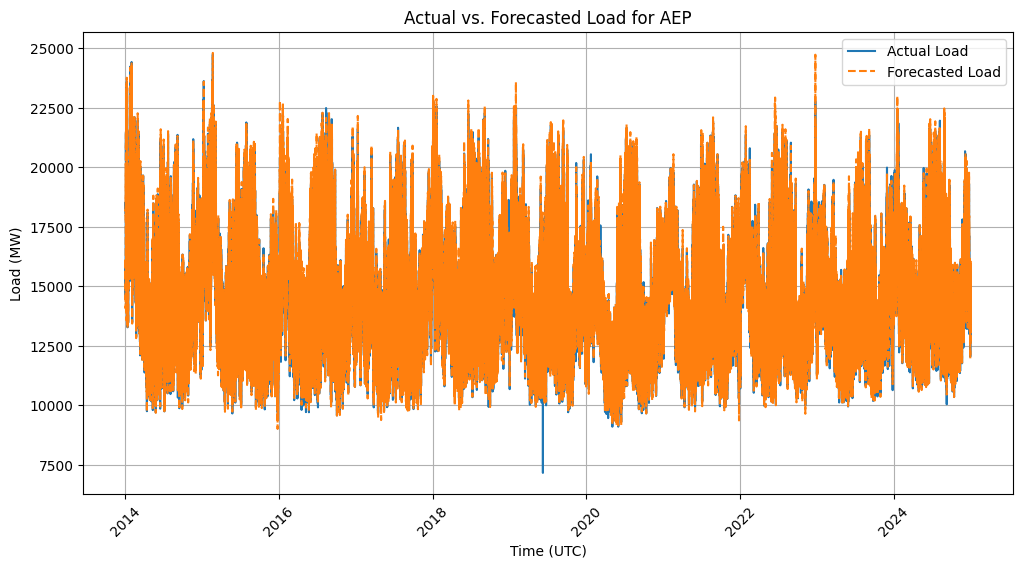

In [12]:
plot_actual_vs_forecast(load_actual_df, load_forecast_df, "AEP")


## Plots actual vs. forecasted for specific dates

In [13]:
def plot_actual_vs_most_recent_forecast_with_dates(load_actual_df, load_forecast_df, zone, start_date, end_date):
    """
    Function that plots a line graph comparing actual load vs. forecasted load over time for a given zone,
    within a specified date range, using vectorized operations.

    Parameters:
        load_actual_df (pd.DataFrame): DataFrame containing actual load data.
        load_forecast_df (pd.DataFrame): DataFrame containing forecasted load data.
        zone (str): The zone to analyze.
        start_date (str or datetime): The start date for filtering the data (YYYY-MM-DD).
        end_date (str or datetime): The end date for filtering the data (YYYY-MM-DD).

    Returns:
        None (displays the plot).
    """
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    actual_filtered = (
        load_actual_df.query("zone == @zone and @start_date <= datetime_beginning_utc <= @end_date")
        .groupby("datetime_beginning_utc", as_index=False)["mw"]
        .sum()
        .rename(columns={"mw": "actual_load_mw"})
    )
    
    forecast_filtered = (
        load_forecast_df
        .assign(lead_time_hours=lambda df: (
            (df["forecast_hour_beginning_utc"] - df["evaluated_at_utc"])
            / pd.Timedelta("1H")
        ))
        .query("forecast_area == @zone and @start_date <= forecast_hour_beginning_utc <= @end_date")
        .sort_values(["forecast_hour_beginning_utc", "evaluated_at_utc"], ascending=[True, False])
        .drop_duplicates(subset=["forecast_hour_beginning_utc"], keep="first")
        .rename(columns={"forecast_load_mw": "forecasted_load_mw"})
    )
    
    merged_df = actual_filtered.merge(
        forecast_filtered,
        left_on="datetime_beginning_utc",
        right_on="forecast_hour_beginning_utc",
        how="left"
    ).sort_values(by="datetime_beginning_utc")

    plt.figure(figsize=(12, 6))
    plt.plot(merged_df["datetime_beginning_utc"], merged_df["actual_load_mw"], label="Actual Load", linestyle="-")
    plt.plot(merged_df["datetime_beginning_utc"], merged_df["forecasted_load_mw"], label="Forecasted Load", linestyle="--")

    plt.xlabel("Time (UTC)")
    plt.ylabel("Load (MW)")
    plt.title(f"Actual vs. Most Recently Forecasted Load for {zone} ({start_date.date()} to {end_date.date()})")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


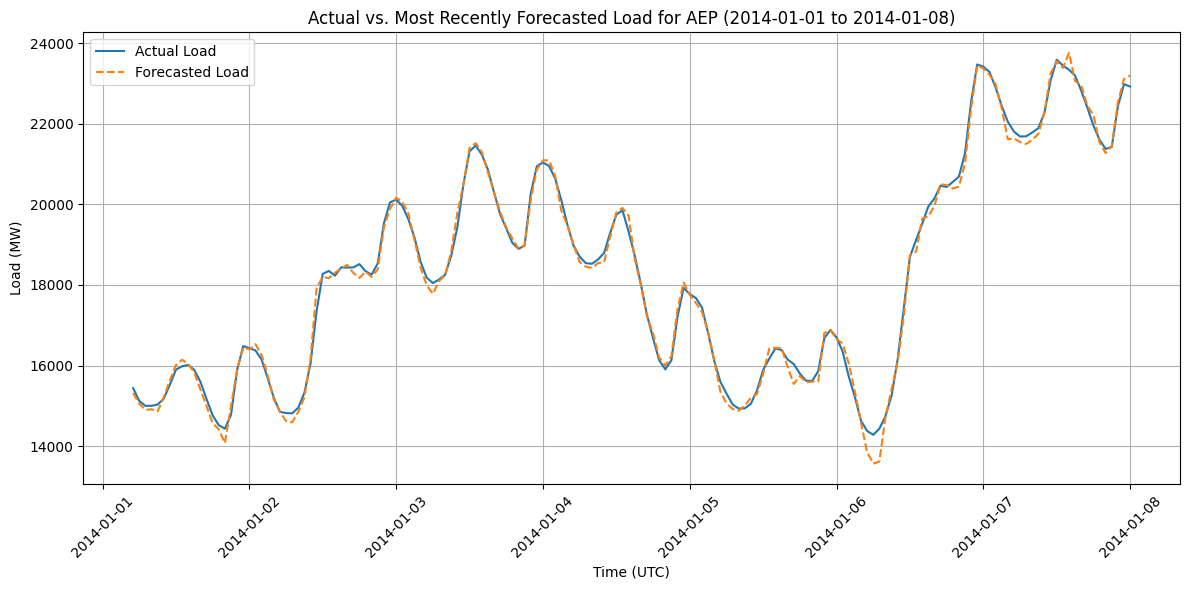

In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

plot_actual_vs_most_recent_forecast_with_dates(load_actual_df, load_forecast_df, "AEP", "2014-01-01", "2014-01-08")


## Calculates error metrics

In [15]:
def calculate_forecast_errors(load_actual_df, load_forecast_df, zone, start_date, end_date):
    """
    Function that calculates RMSE, Bias, MPE, and MAE for actual vs. forecasted load within a given date range,
    using vectorized operations and leveraging the get_most_recent_forecast() function efficiently.

    Parameters:
        load_actual_df (pd.DataFrame): DataFrame containing actual load data.
        load_forecast_df (pd.DataFrame): DataFrame containing forecasted load data.
        zone (str): The zone to analyze.
        start_date (str or datetime): The start date for filtering the data (YYYY-MM-DD).
        end_date (str or datetime): The end date for filtering the data (YYYY-MM-DD).

    Returns:
        dict: Dictionary containing RMSE, Bias, MPE, and MAE.
    """
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    actual_filtered = (
        load_actual_df.query("zone == @zone and @start_date <= datetime_beginning_utc <= @end_date")
        .groupby("datetime_beginning_utc", as_index=False)["mw"]
        .sum()
        .rename(columns={"mw": "actual_load_mw"})
    )

    timestamps = actual_filtered["datetime_beginning_utc"].to_numpy()

    forecasted_loads = np.array([get_most_recent_forecast(load_forecast_df, ts, zone) for ts in timestamps])

    valid_indices = ~np.isnan(forecasted_loads)
    actual_loads = actual_filtered["actual_load_mw"].to_numpy()[valid_indices]
    forecasted_loads = forecasted_loads[valid_indices]

    if len(actual_loads) == 0:
        return {"RMSE": None, "Bias": None, "MPE (%)": None, "MAE": None}

    return {
        "RMSE": np.sqrt(mean_squared_error(actual_loads, forecasted_loads)),
        "Bias": np.mean(forecasted_loads - actual_loads),
        "MPE (%)": np.mean((forecasted_loads - actual_loads) / actual_loads) * 100,
        "MAE": mean_absolute_error(actual_loads, forecasted_loads)
    }

In [16]:
error_metrics = calculate_forecast_errors(load_actual_df, load_forecast_df, "AEP", "2020-01-01", "2020-01-08")
print(error_metrics)

{'RMSE': np.float64(381.2586572573307), 'Bias': np.float64(58.198526627218854), 'MPE (%)': np.float64(0.4078343533388051), 'MAE': 308.3609881656805}


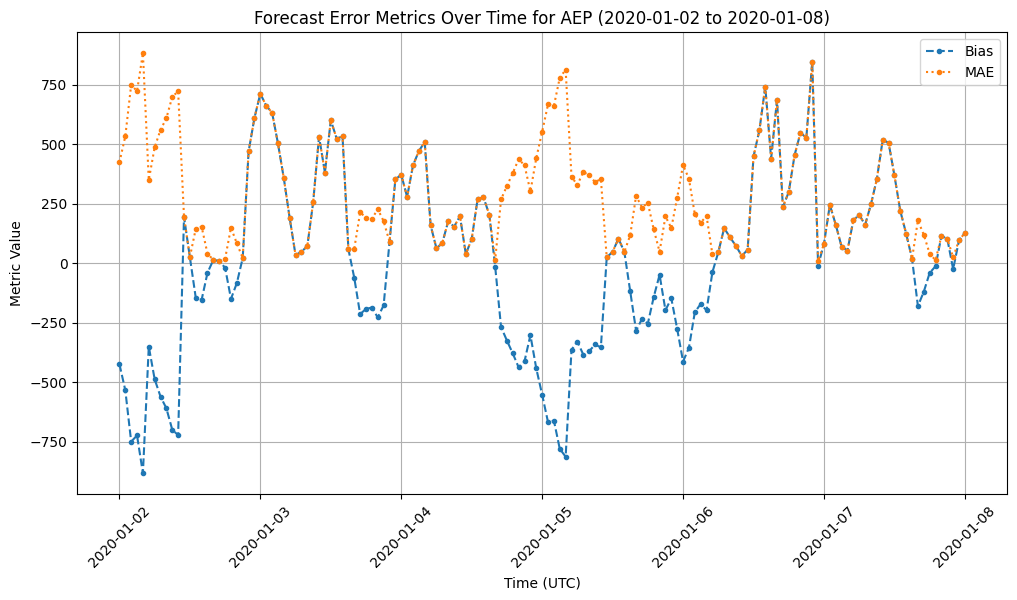

In [17]:
def plot_forecast_metrics_over_time(load_actual_df, load_forecast_df, zone, start_date, end_date):
    """
    Function that plots RMSE, Bias, MPE, and MAE over time for a given zone,
    using vectorized operations and efficient rolling calculations.

    Parameters:
        load_actual_df (pd.DataFrame): DataFrame containing actual load data.
        load_forecast_df (pd.DataFrame): DataFrame containing forecasted load data.
        zone (str): The zone to analyze.
        start_date (str or datetime): The start date for filtering the data (YYYY-MM-DD).
        end_date (str or datetime): The end date for filtering the data (YYYY-MM-DD).

    Returns:
        None (displays the plot).
    """
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    actual_filtered = (
        load_actual_df.query("zone == @zone and @start_date <= datetime_beginning_utc <= @end_date")
        .groupby("datetime_beginning_utc", as_index=False)["mw"]
        .sum()
        .rename(columns={"mw": "actual_load_mw"})
    )

    timestamps = actual_filtered["datetime_beginning_utc"].to_numpy()

    forecasted_loads = np.array([get_most_recent_forecast(load_forecast_df, ts, zone) for ts in timestamps])

    valid_indices = ~np.isnan(forecasted_loads)
    actual_loads = actual_filtered["actual_load_mw"].to_numpy()[valid_indices]
    forecasted_loads = forecasted_loads[valid_indices]
    timestamps = timestamps[valid_indices]

    if len(actual_loads) == 0:
        print(f"No valid data for {zone} in the given date range.")
        return

    bias_values = pd.Series(forecasted_loads - actual_loads)
    mae_values = pd.Series(np.abs(forecasted_loads - actual_loads))

    metrics_df = pd.DataFrame({
        "Timestamp": timestamps,
        "Bias": bias_values,
        "MAE": mae_values
    })

    plt.figure(figsize=(12, 6))
    plt.plot(metrics_df["Timestamp"], metrics_df["Bias"], label="Bias", linestyle="--", marker=".")
    plt.plot(metrics_df["Timestamp"], metrics_df["MAE"], label="MAE", linestyle=":", marker=".")

    plt.xlabel("Time (UTC)") 
    plt.ylabel("Metric Value")
    plt.title(f"Forecast Error Metrics Over Time for {zone} ({start_date.date()} to {end_date.date()})")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

plot_forecast_metrics_over_time(load_actual_df, load_forecast_df, "AEP", "2020-01-02", "2020-01-08")

## Finding the different lead times

In [18]:
load_forecast_df["lead_time_hours"] = (
    (load_forecast_df["forecast_hour_beginning_utc"] - load_forecast_df["evaluated_at_utc"]).dt.total_seconds() / 3600
)

unique_lead_times = load_forecast_df["lead_time_hours"].unique()

print(f"Total Unique Lead Times: {len(unique_lead_times)}")
print("Lead Times (in hours):")
print(sorted(unique_lead_times))


Total Unique Lead Times: 136
Lead Times (in hours):
[np.float64(-24.75), np.float64(-23.75), np.float64(-22.759166666666665), np.float64(-22.75), np.float64(-22.0), np.float64(-21.75), np.float64(-20.75), np.float64(-19.75), np.float64(-18.75), np.float64(-17.75), np.float64(-16.759166666666665), np.float64(-16.75), np.float64(-16.0), np.float64(-15.75), np.float64(-14.75), np.float64(-13.75), np.float64(-12.75), np.float64(-11.75), np.float64(-10.759166666666667), np.float64(-10.75), np.float64(-10.0), np.float64(-9.75), np.float64(-8.759166666666667), np.float64(-8.75), np.float64(-8.0), np.float64(-7.75), np.float64(-6.75), np.float64(-5.75), np.float64(-4.759166666666666), np.float64(-4.75), np.float64(-4.0), np.float64(-3.75), np.float64(-2.75), np.float64(-1.75), np.float64(-0.75), np.float64(0.25), np.float64(1.25), np.float64(2.2408333333333332), np.float64(2.25), np.float64(3.0), np.float64(3.25), np.float64(4.25), np.float64(5.25), np.float64(6.25), np.float64(7.25), np.float

## Plots actual vs. forecasted with specific lead times

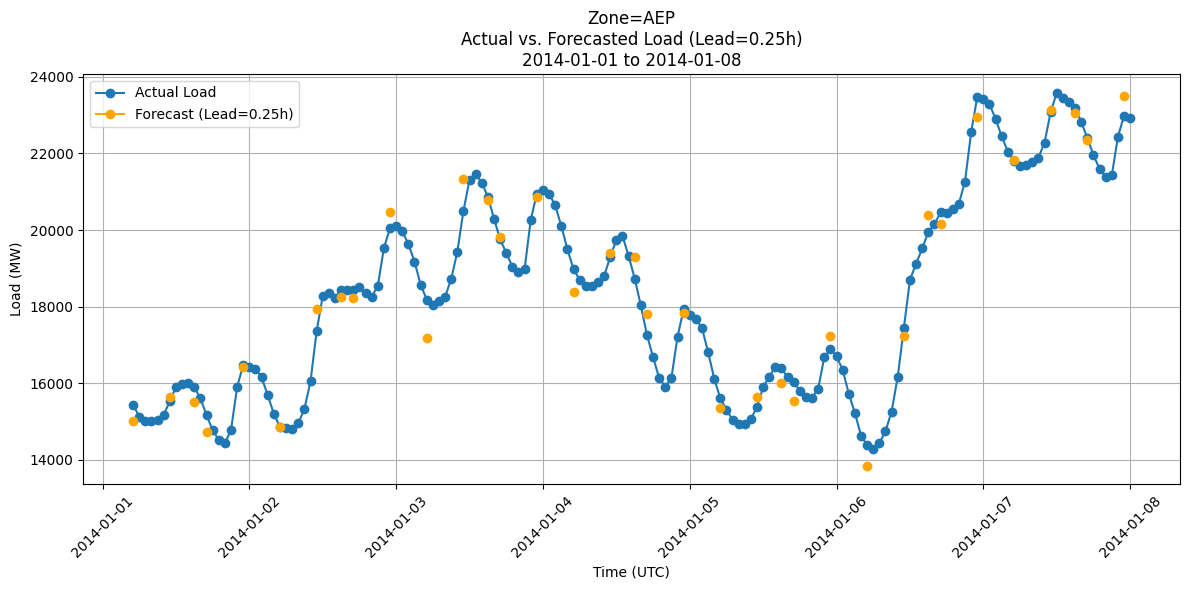

In [19]:
def plot_actual_vs_forecast_with_lead_time(
    load_actual_df, 
    load_forecast_df, 
    zone, 
    start_date, 
    end_date, 
    chosen_lead_time
):
    """
    Plots a line graph comparing actual load vs. forecasted load over time for
    a given zone, within a specified date range, using only forecasts that have
    an EXACT chosen lead time (and ignoring any negative lead times).

    Parameters:
        load_actual_df (pd.DataFrame): DataFrame containing actual load data.
                                       Must have columns:
                                         - 'zone'
                                         - 'datetime_beginning_utc'
                                         - 'mw'
        load_forecast_df (pd.DataFrame): DataFrame containing forecast data.
                                         Must have columns:
                                           - 'forecast_area'
                                           - 'forecast_hour_beginning_utc'
                                           - 'evaluated_at_utc'
                                           - 'forecast_load_mw'
        zone (str): The zone to analyze.
        start_date (str or datetime): The start date for filtering data (YYYY-MM-DD).
        end_date (str or datetime): The end date for filtering data (YYYY-MM-DD).
        chosen_lead_time (float): The exact forecast lead time (in hours) to keep.

    Returns:
        None (displays the plot).
    """
    start_dt = pd.to_datetime(start_date, utc=True)
    end_dt = pd.to_datetime(end_date, utc=True)

    load_actual_df["datetime_beginning_utc"] = pd.to_datetime(load_actual_df["datetime_beginning_utc"], utc=True)
    load_forecast_df["forecast_hour_beginning_utc"] = pd.to_datetime(load_forecast_df["forecast_hour_beginning_utc"], utc=True)
    load_forecast_df["evaluated_at_utc"] = pd.to_datetime(load_forecast_df["evaluated_at_utc"], utc=True)

    load_forecast_df["forecast_area"] = load_forecast_df["forecast_area"].str.strip()

    actual_filtered = (
        load_actual_df
        .query("zone == @zone and @start_dt <= datetime_beginning_utc <= @end_dt")
        .groupby("datetime_beginning_utc", as_index=False)["mw"]
        .sum()
        .rename(columns={"mw": "actual_load_mw"})
    )

    forecast_filtered = (
        load_forecast_df
        .assign(lead_time_hours=lambda df: (
            (df["forecast_hour_beginning_utc"] - df["evaluated_at_utc"]) 
            / pd.Timedelta(hours=1)
        ))
        .query(
            "forecast_area == @zone "
            "and @start_dt <= forecast_hour_beginning_utc <= @end_dt "
            "and lead_time_hours >= 0 "
        )
    )
    
    forecast_filtered = forecast_filtered[
        forecast_filtered["lead_time_hours"].round(2) == chosen_lead_time
    ]

    forecast_filtered = (
        forecast_filtered
        .sort_values(["forecast_hour_beginning_utc", "evaluated_at_utc"], ascending=[True, False])
        .drop_duplicates(subset=["forecast_hour_beginning_utc"], keep="first")
        .rename(columns={"forecast_load_mw": "forecasted_load_mw"})
    )

    merged_df = pd.merge(
        actual_filtered,
        forecast_filtered,
        left_on="datetime_beginning_utc",
        right_on="forecast_hour_beginning_utc",
        how="left"
    ).sort_values(by="datetime_beginning_utc")
    
    plt.figure(figsize=(12, 6))
    plt.plot(
        merged_df["datetime_beginning_utc"], 
        merged_df["actual_load_mw"], 
        label="Actual Load", 
        linestyle="-", 
        marker="o"
    )
    plt.plot(
    merged_df["datetime_beginning_utc"], 
    merged_df["forecasted_load_mw"], 
    label=f"Forecast (Lead={chosen_lead_time}h)", 
    linestyle="-",
    marker="o",
    color="orange"
)

    plt.xlabel("Time (UTC)")
    plt.ylabel("Load (MW)")
    plt.title(f"Zone={zone}\nActual vs. Forecasted Load (Lead={chosen_lead_time}h)\n{start_dt.date()} to {end_dt.date()}")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_actual_vs_forecast_with_lead_time(load_actual_df, load_forecast_df, 'AEP', "2014-01-01", "2014-01-08", 0.25)

## Plots actual vs forecasted with multiple lead times

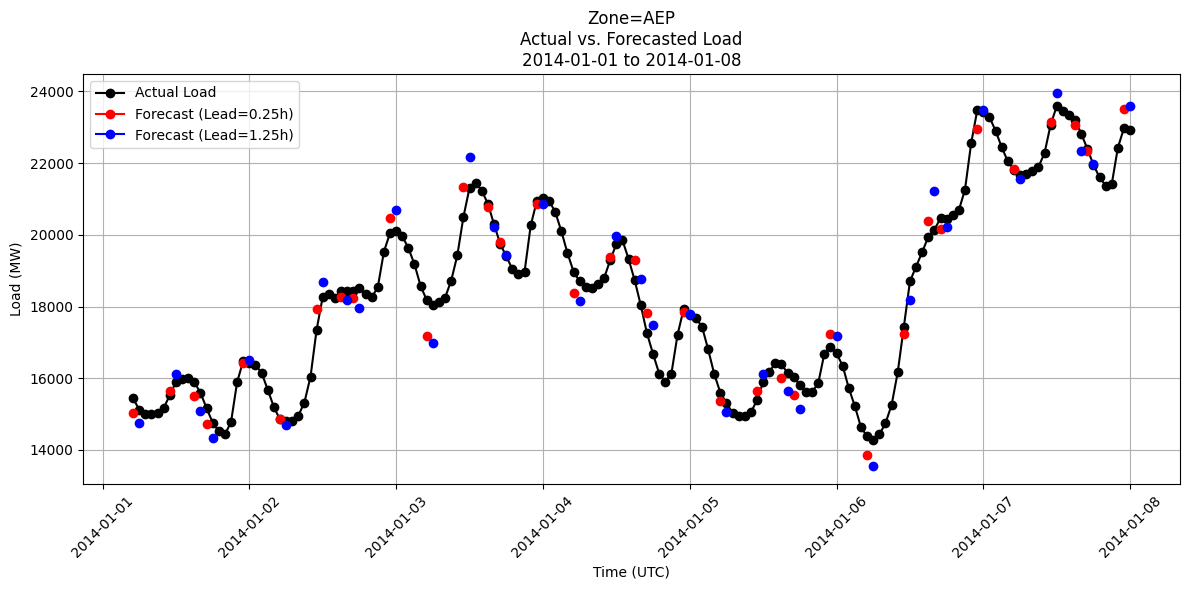

In [20]:
def plot_actual_vs_forecast_with_multiple_lead_times(
    load_actual_df, 
    load_forecast_df, 
    zone, 
    start_date, 
    end_date, 
    chosen_lead_times
):
    """
    Plots a line graph comparing actual load vs. forecasted load over time for
    a given zone, within a specified date range, using multiple chosen lead times.

    Parameters:
        load_actual_df (pd.DataFrame): DataFrame containing actual load data.
                                       Must have columns:
                                         - 'zone'
                                         - 'datetime_beginning_utc'
                                         - 'mw'
        load_forecast_df (pd.DataFrame): DataFrame containing forecast data.
                                         Must have columns:
                                           - 'forecast_area'
                                           - 'forecast_hour_beginning_utc'
                                           - 'evaluated_at_utc'
                                           - 'forecast_load_mw'
        zone (str): The zone to analyze.
        start_date (str or datetime): The start date for filtering data (YYYY-MM-DD).
        end_date (str or datetime): The end date for filtering data (YYYY-MM-DD).
        chosen_lead_times (list of float): List of exact forecast lead times (in hours) to plot.

    Returns:
        None (displays the plot).
    """
    start_dt = pd.to_datetime(start_date, utc=True)
    end_dt = pd.to_datetime(end_date, utc=True)

    load_actual_df["datetime_beginning_utc"] = pd.to_datetime(load_actual_df["datetime_beginning_utc"], utc=True)
    load_forecast_df["forecast_hour_beginning_utc"] = pd.to_datetime(load_forecast_df["forecast_hour_beginning_utc"], utc=True)
    load_forecast_df["evaluated_at_utc"] = pd.to_datetime(load_forecast_df["evaluated_at_utc"], utc=True)
    load_forecast_df["forecast_area"] = load_forecast_df["forecast_area"].str.strip()

    actual_filtered = (
        load_actual_df
        .query("zone == @zone and @start_dt <= datetime_beginning_utc <= @end_dt")
        .groupby("datetime_beginning_utc", as_index=False)["mw"]
        .sum()
        .rename(columns={"mw": "actual_load_mw"})
    )

    load_forecast_df = load_forecast_df.assign(
        lead_time_hours=lambda df: (
            (df["forecast_hour_beginning_utc"] - df["evaluated_at_utc"]) 
            / pd.Timedelta(hours=1)
        )
    )

    forecast_filtered = load_forecast_df.query(
        "forecast_area == @zone "
        "and @start_dt <= forecast_hour_beginning_utc <= @end_dt "
        "and lead_time_hours >= 0"
    )
    
    plt.figure(figsize=(12, 6))
    plt.plot(
        actual_filtered["datetime_beginning_utc"], 
        actual_filtered["actual_load_mw"], 
        label="Actual Load", 
        linestyle="-", 
        marker="o",
        color="black"
    )
    
    colors = ["red", "blue", "green", "purple", "orange", "brown", "pink", "gray", "cyan", "magenta"]
    
    for lead_time, color in zip(chosen_lead_times, colors[:len(chosen_lead_times)]):
        lead_filtered = forecast_filtered[forecast_filtered["lead_time_hours"].round(2) == lead_time]
        lead_filtered = (
            lead_filtered
            .sort_values(["forecast_hour_beginning_utc", "evaluated_at_utc"], ascending=[True, False])
            .drop_duplicates(subset=["forecast_hour_beginning_utc"], keep="first")
            .rename(columns={"forecast_load_mw": "forecasted_load_mw"})
        )
        
        merged_df = pd.merge(
            actual_filtered,
            lead_filtered,
            left_on="datetime_beginning_utc",
            right_on="forecast_hour_beginning_utc",
            how="left"
        ).sort_values(by="datetime_beginning_utc")
        
        plt.plot(
            merged_df["datetime_beginning_utc"], 
            merged_df["forecasted_load_mw"], 
            label=f"Forecast (Lead={lead_time}h)", 
            linestyle="-", 
            marker="o", 
            color=color
        )
    
    plt.xlabel("Time (UTC)")
    plt.ylabel("Load (MW)")
    plt.title(f"Zone={zone}\nActual vs. Forecasted Load\n{start_dt.date()} to {end_dt.date()}")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
plot_actual_vs_forecast_with_multiple_lead_times(load_actual_df, load_forecast_df, 'AEP', "2014-01-01", "2014-01-08", [.25, 1.25])

## Calculates how many forecasts are made at a specific initialization time

In [21]:
def calculate_avg_forecasts_per_init_time(load_forecast_df, forecast_area):
    """
    Computes the average number of forecasts made at each forecast initialization time (04:45, 10:45, 16:45, 22:45 UTC) 
    for a specified forecast area.

    Parameters:
        load_forecast_df (pd.DataFrame): DataFrame containing forecast data with 'evaluated_at_utc' and 'forecast_area'.
        forecast_area (str): The specific forecast area to analyze (e.g., "AEP").

    Returns:
        pd.DataFrame: DataFrame with average forecasts made at each initialization time for the specified area.
    """
    load_forecast_df["evaluated_at_utc"] = pd.to_datetime(load_forecast_df["evaluated_at_utc"])

    filtered_df = load_forecast_df[load_forecast_df["forecast_area"] == forecast_area].copy()

    filtered_df["init_time"] = filtered_df["evaluated_at_utc"].dt.strftime("%H:%M")

    forecast_times = ["04:45", "10:45", "16:45", "22:45"]
    filtered_df = filtered_df[filtered_df["init_time"].isin(forecast_times)]

    filtered_df["date"] = filtered_df["evaluated_at_utc"].dt.date
    forecast_counts = filtered_df.groupby(["date", "init_time"]).size().reset_index(name="num_forecasts")

    avg_forecasts = forecast_counts.groupby("init_time")["num_forecasts"].mean().reset_index()

    avg_forecasts = avg_forecasts.sort_values(by="init_time")

    print(f"\nAverage Number of Forecasts Per Initialization Time for {forecast_area}:")
    print(avg_forecasts)

    return avg_forecasts

avg_forecasts_AEP = calculate_avg_forecasts_per_init_time(load_forecast_df, "AEP")



Average Number of Forecasts Per Initialization Time for AEP:
  init_time  num_forecasts
0     04:45      34.723810
1     10:45      45.503693
2     16:45      41.886918
3     22:45      38.208426


## Most common initialization times

In [22]:
time_counts = load_forecast_df["evaluated_at_utc"].dt.strftime("%H:%M").value_counts().sort_index()

print("Most common evaluated_at_utc times (HH:MM) and their occurrences:")
print(time_counts)

Most common evaluated_at_utc times (HH:MM) and their occurrences:
evaluated_at_utc
03:00         18
03:45     952698
04:00         18
04:45     513192
09:00         18
09:45    1282002
10:00         18
10:45     668770
13:00         18
13:45    1173506
14:00         18
14:45     628440
15:00         18
15:45    1172250
16:00         17
16:45     614957
21:00         18
21:45    1062282
22:00         18
22:45     560614
Name: count, dtype: int64


## Largest discrepancies within an specific zone and time period

In [23]:
def get_top_forecast_discrepancies(load_actual_df, load_forecast_df, zone, start_year, end_year, lead_time, top_n=5):
    """
    Finds the top N largest discrepancies between forecasted load and actual load for a given region, timeframe, and lead time.

    Parameters:
        load_actual_df (pd.DataFrame): DataFrame containing actual load data.
        load_forecast_df (pd.DataFrame): DataFrame containing forecasted load data.
        zone (str): The region to analyze.
        start_year (int): The start year for filtering data.
        end_year (int): The end year for filtering data.
        lead_time (float): The exact forecast lead time (in hours) to consider.
        top_n (int, optional): The number of top discrepancies to return. Defaults to 5.

    Returns:
        pd.DataFrame: A DataFrame containing the top N discrepancies sorted by absolute error.
    """
    load_actual_df["datetime_beginning_utc"] = pd.to_datetime(load_actual_df["datetime_beginning_utc"], utc=True)
    load_forecast_df["forecast_hour_beginning_utc"] = pd.to_datetime(load_forecast_df["forecast_hour_beginning_utc"], utc=True)
    load_forecast_df["evaluated_at_utc"] = pd.to_datetime(load_forecast_df["evaluated_at_utc"], utc=True)
    
    start_date = pd.to_datetime(f"{start_year}-01-01", utc=True)
    end_date = pd.to_datetime(f"{end_year}-12-31", utc=True)
    
    actual_filtered = (
        load_actual_df.query("zone == @zone and @start_date <= datetime_beginning_utc <= @end_date")
        .groupby("datetime_beginning_utc", as_index=False)["mw"]
        .sum()
        .rename(columns={"mw": "actual_load_mw"})
    )
    
    load_forecast_df = load_forecast_df.assign(
        lead_time_hours=lambda df: (
            (df["forecast_hour_beginning_utc"] - df["evaluated_at_utc"]) / pd.Timedelta(hours=1)
        )
    )
    
    forecast_filtered = (
        load_forecast_df.query(
            "forecast_area == @zone and @start_date <= forecast_hour_beginning_utc <= @end_date and lead_time_hours >= 0"
        )
    )
    
    forecast_filtered = forecast_filtered[forecast_filtered["lead_time_hours"].round(2) == lead_time]
    
    forecast_filtered = (
        forecast_filtered
        .sort_values(["forecast_hour_beginning_utc", "evaluated_at_utc"], ascending=[True, False])
        .drop_duplicates(subset=["forecast_hour_beginning_utc"], keep="first")
        .rename(columns={"forecast_load_mw": "forecasted_load_mw"})
    )
    
    merged_df = pd.merge(
        actual_filtered,
        forecast_filtered,
        left_on="datetime_beginning_utc",
        right_on="forecast_hour_beginning_utc",
        how="left"
    ).sort_values(by="datetime_beginning_utc")
    
    merged_df["absolute_error"] = np.abs(merged_df["actual_load_mw"] - merged_df["forecasted_load_mw"])
    
    top_discrepancies = merged_df.nlargest(top_n, "absolute_error")
    
    print(f"Top {top_n} forecast discrepancies for {zone} from {start_year} to {end_year} with lead time {lead_time}h:")
    print(top_discrepancies[["datetime_beginning_utc", "actual_load_mw", "forecasted_load_mw", "absolute_error"]])
    
    return top_discrepancies

top_discrepancies = get_top_forecast_discrepancies(load_actual_df, load_forecast_df, "EKPC", 2020, 2024, 0.25)

Top 5 forecast discrepancies for EKPC from 2020 to 2024 with lead time 0.25h:
         datetime_beginning_utc  actual_load_mw  forecasted_load_mw  \
38512 2024-05-23 16:00:00+00:00        1427.492              9101.0   
26117 2022-12-24 05:00:00+00:00        3452.391              2616.0   
26105 2022-12-23 17:00:00+00:00        3601.889              2830.0   
26103 2022-12-23 15:00:00+00:00        3657.432              3220.0   
40174 2024-07-31 22:00:00+00:00        1954.833              2344.0   

       absolute_error  
38512        7673.508  
26117         836.391  
26105         771.889  
26103         437.432  
40174         389.167  


## Largest discrepancies within all zones and a specific time period

In [24]:
def get_top_forecast_discrepancies_all_zones(load_actual_df, load_forecast_df, start_year, end_year, lead_time, top_n=5):
    """
    Finds the top N largest discrepancies between forecasted load and actual load across all regions except RTO, 
    within a given timeframe and lead time.

    Parameters:
        load_actual_df (pd.DataFrame): DataFrame containing actual load data.
        load_forecast_df (pd.DataFrame): DataFrame containing forecasted load data.
        start_year (int): The start year for filtering data.
        end_year (int): The end year for filtering data.
        lead_time (float): The exact forecast lead time (in hours) to consider.
        top_n (int, optional): The number of top discrepancies to return. Defaults to 5.

    Returns:
        pd.DataFrame: A DataFrame containing the top N discrepancies sorted by absolute error across all zones except RTO.
    """
    load_actual_df["datetime_beginning_utc"] = pd.to_datetime(load_actual_df["datetime_beginning_utc"], utc=True)
    load_forecast_df["forecast_hour_beginning_utc"] = pd.to_datetime(load_forecast_df["forecast_hour_beginning_utc"], utc=True)
    load_forecast_df["evaluated_at_utc"] = pd.to_datetime(load_forecast_df["evaluated_at_utc"], utc=True)

    start_date = pd.to_datetime(f"{start_year}-01-01", utc=True)
    end_date = pd.to_datetime(f"{end_year}-12-31", utc=True)

    for col in ["zone", "datetime_beginning_utc", "mw"]:
        if col not in load_actual_df.columns:
            raise KeyError(f"Missing '{col}' column in actual load data.")

    for col in ["forecast_area", "forecast_hour_beginning_utc", "evaluated_at_utc", "forecast_load_mw"]:
        if col not in load_forecast_df.columns:
            raise KeyError(f"Missing '{col}' column in forecast data.")

    actual_filtered = (
        load_actual_df.query("@start_date <= datetime_beginning_utc <= @end_date and zone != 'RTO'")
        .groupby(["zone", "datetime_beginning_utc"], as_index=False)["mw"]
        .sum()
        .rename(columns={"mw": "actual_load_mw"})
    )

    load_forecast_df["lead_time_hours"] = (
        (load_forecast_df["forecast_hour_beginning_utc"] - load_forecast_df["evaluated_at_utc"]) / pd.Timedelta(hours=1)
    )

    forecast_filtered = load_forecast_df.query(
        "@start_date <= forecast_hour_beginning_utc <= @end_date and lead_time_hours >= 0"
    )

    forecast_filtered = forecast_filtered[forecast_filtered["lead_time_hours"].round(2) == lead_time]

    forecast_filtered = (
        forecast_filtered
        .sort_values(["forecast_area", "forecast_hour_beginning_utc", "evaluated_at_utc"], ascending=[True, True, False])
        .drop_duplicates(subset=["forecast_area", "forecast_hour_beginning_utc"], keep="first")
        .rename(columns={"forecast_load_mw": "forecasted_load_mw", "forecast_area": "zone"})
    )

    forecast_filtered = forecast_filtered.query("zone != 'RTO'")

    forecast_filtered = forecast_filtered.rename(columns={"forecast_hour_beginning_utc": "datetime_beginning_utc"})

    merged_df = pd.merge(
        actual_filtered,
        forecast_filtered,
        on=["zone", "datetime_beginning_utc"],
        how="inner"
    )

    merged_df["absolute_error"] = np.abs(merged_df["actual_load_mw"] - merged_df["forecasted_load_mw"])

    top_discrepancies = merged_df.nlargest(top_n, "absolute_error")

    print(f"Top {top_n} forecast discrepancies across all zones (excluding RTO) from {start_year} to {end_year} with lead time {lead_time}h:")
    print(top_discrepancies[["zone", "datetime_beginning_utc", "actual_load_mw", "forecasted_load_mw", "absolute_error"]])

    return top_discrepancies

top_discrepancies_all = get_top_forecast_discrepancies_all_zones(load_actual_df, load_forecast_df, 2014, 2024, 0.25)


Top 5 forecast discrepancies across all zones (excluding RTO) from 2014 to 2024 with lead time 0.25h:
        zone    datetime_beginning_utc  actual_load_mw  forecasted_load_mw  \
133310  EKPC 2024-05-23 16:00:00+00:00        1427.492              9101.0   
77617    DOM 2014-07-23 22:00:00+00:00       14256.460             17516.0   
78204    DOM 2014-11-18 11:00:00+00:00       10292.274             13546.0   
77866    DOM 2014-09-11 16:00:00+00:00       11625.246             14344.0   
18217    AEP 2024-02-01 17:00:00+00:00       13716.342             16141.0   

        absolute_error  
133310        7673.508  
77617         3259.540  
78204         3253.726  
77866         2718.754  
18217         2424.658  


## A look at the effects of Prime Day on Northern Virginia's load (Amazon data center effects)

In [26]:
# Prime Day periods (UTC time range)
prime_days = [
    ("2020-10-13 07:00:00", "2020-10-15 06:59:59"),
    ("2021-06-21 07:00:00", "2021-06-23 06:59:59"),
    ("2022-07-12 07:00:00", "2022-07-14 06:59:59"),
    ("2024-07-16 07:00:00", "2024-07-18 06:59:59"),
]

prime_day_ranges = [(pd.to_datetime(start, utc=True), pd.to_datetime(end, utc=True)) for start, end in prime_days]

actual_filtered = load_actual_df.query("zone == 'DOM'").copy()
actual_filtered = actual_filtered[
    actual_filtered["datetime_beginning_utc"].apply(lambda x: any(start <= x <= end for start, end in prime_day_ranges))
].groupby("datetime_beginning_utc", as_index=False)["mw"].sum()
actual_filtered = actual_filtered.rename(columns={"mw": "actual_load_mw"})

forecast_filtered = load_forecast_df.query("forecast_area == 'DOM' and lead_time_hours >= 0").copy()
forecast_filtered = forecast_filtered[forecast_filtered["lead_time_hours"].round(2) == 0.25]

forecast_filtered = forecast_filtered[
    forecast_filtered["forecast_hour_beginning_utc"].apply(lambda x: any(start <= x <= end for start, end in prime_day_ranges))
]

forecast_filtered = (
    forecast_filtered
    .sort_values(["forecast_hour_beginning_utc", "evaluated_at_utc"], ascending=[True, False])
    .drop_duplicates(subset=["forecast_hour_beginning_utc"], keep="first")
    .rename(columns={"forecast_load_mw": "forecasted_load_mw"})
)

merged_df = pd.merge(
    actual_filtered,
    forecast_filtered,
    left_on="datetime_beginning_utc",
    right_on="forecast_hour_beginning_utc",
    how="left"
).sort_values(by="datetime_beginning_utc")

merged_df["absolute_error"] = (merged_df["actual_load_mw"] - merged_df["forecasted_load_mw"]).abs()

merged_df = merged_df.sort_values(by="absolute_error", ascending=False)

top5 = merged_df.sort_values(by="absolute_error", ascending=False).head(5)

print("Top 5 Forecast vs Actual Load Discrepancies for DOM During Prime Day Events:")
print(top5[["datetime_beginning_utc", "actual_load_mw", "forecasted_load_mw", "absolute_error"]].to_string(index=False))

Top 5 Forecast vs Actual Load Discrepancies for DOM During Prime Day Events:
   datetime_beginning_utc  actual_load_mw  forecasted_load_mw  absolute_error
2024-07-17 22:00:00+00:00       20608.580             22128.0        1519.420
2022-07-12 22:00:00+00:00       17947.980             19164.0        1216.020
2024-07-17 14:00:00+00:00       18768.524             19445.0         676.476
2021-06-22 04:00:00+00:00       13301.977             13909.0         607.023
2022-07-13 04:00:00+00:00       12825.281             13413.0         587.719
